# Benchmark v5 — CPU — ESOL — random split, seed 4

**Task:** Predict `log(mol/L)` solubility from molecular structure.
**Size:** ~1,128 molecules
**Metric:** RMSE ↓, MAE ↓, R² ↑

**Random split** (80/10/10), seed **4**. Tabular HPO on train; metrics on the held-out test set.

Results go to `results/seed_4/random/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (CPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (CPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "esol"
TASK_TYPE = "regression"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 120
LSTM_EPOCHS = 120
TOX21_TABULAR = False

SPLIT_MODE = "random"   # "scaffold" or "random"
SPLIT_SEED = 4

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "cpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random
SPLIT_SEED=4  mode=random


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("esol", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "esol")
print(f"Molecules : {len(smiles)}")
print(f"Target    : [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'esol' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/esol.csv
INFO | [esol] 1128 / 1128 valid molecules


Molecules : 1128
Target    : [-11.60, 1.58]  mean=-3.05
After bond filter: 1127 molecules


### Random split


In [4]:
split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
# Guard: v4's malformed-split failure mode can never pass silently now.
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])


INFO | Saved random split → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/splits/esol_random_splits.pkl (train=901, val=112, test=114, scaffolds=269)


{'n_total': 1127, 'n_train': 901, 'n_val': 112, 'n_test': 114, 'n_scaffolds_total': 269, 'n_scaffolds_train': 229, 'n_scaffolds_val': 38, 'n_scaffolds_test': 51}


### Representations


In [5]:
X_morgan = smiles_to_morgan(smiles)
X_desc = smiles_to_descriptors(smiles)
X_combined = smiles_to_combined(smiles)
print(X_morgan.shape, X_desc.shape, X_combined.shape)


(1127, 2048) (1127, 217) (1127, 2265)


### Morgan + RF


In [6]:
MODEL_KEY = "Morgan + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Morgan + RF (HPO on train=901, test=114) …


INFO | Saved Morgan + RF → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_partial.json


   best params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 130}
   test metrics: {'RMSE': (1.1965392448517975, 0.0), 'MAE': (0.9367876553834278, 0.0), 'R2': (0.6492176990649678, 0.0)}


### Morgan + SVM


In [7]:
MODEL_KEY = "Morgan + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Morgan + SVM (HPO on train=901, test=114) …


INFO | Saved Morgan + SVM → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_partial.json


   best params: {'C': 62.50420376693001, 'gamma': 'auto'}
   test metrics: {'RMSE': (1.3166400713035415, 0.0), 'MAE': (1.0308738819113827, 0.0), 'R2': (0.5752651326276865, 0.0)}


### Morgan + XGBoost


In [8]:
MODEL_KEY = "Morgan + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Morgan + XGBoost (HPO on train=901, test=114) …


INFO | Saved Morgan + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_partial.json


   best params: {'colsample_bytree': 0.7425492358351505, 'learning_rate': 0.17407830689206583, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 287, 'subsample': 0.8933764602572152}
   test metrics: {'RMSE': (1.0817607501319093, 0.0), 'MAE': (0.7958953858932906, 0.0), 'R2': (0.7132877710038902, 0.0)}


### Descriptors + RF


In [9]:
MODEL_KEY = "Descriptors + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Descriptors + RF (HPO on train=901, test=114) …


INFO | Saved Descriptors + RF → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_partial.json


   best params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 130}
   test metrics: {'RMSE': (0.7248915924143214, 0.0), 'MAE': (0.5444393258836683, 0.0), 'R2': (0.8712551389347316, 0.0)}


### Descriptors + SVM


In [10]:
MODEL_KEY = "Descriptors + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Descriptors + SVM (HPO on train=901, test=114) …


INFO | Saved Descriptors + SVM → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_partial.json


   best params: {'C': 17.548839549333973, 'gamma': 'auto'}
   test metrics: {'RMSE': (0.8051615011179745, 0.0), 'MAE': (0.5441892378193605, 0.0), 'R2': (0.8411636936073337, 0.0)}


### Descriptors + XGBoost


In [11]:
MODEL_KEY = "Descriptors + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Descriptors + XGBoost (HPO on train=901, test=114) …


INFO | Saved Descriptors + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_partial.json


   best params: {'colsample_bytree': 0.7451414353732506, 'learning_rate': 0.03795824955047764, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 225, 'subsample': 0.6302825486136835}
   test metrics: {'RMSE': (0.7012118487222648, 0.0), 'MAE': (0.5231985747249502, 0.0), 'R2': (0.8795290681804523, 0.0)}


### Combined + XGBoost


In [12]:
MODEL_KEY = "Combined + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_combined, train_idx)
    X_te = subset_array(X_combined, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Combined + XGBoost (HPO on train=901, test=114) …


INFO | Saved Combined + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_partial.json


   best params: {'colsample_bytree': 0.8930373794359872, 'learning_rate': 0.16449766277417044, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 197, 'subsample': 0.6257005484851235}
   test metrics: {'RMSE': (0.6857071390653593, 0.0), 'MAE': (0.5214341509572247, 0.0), 'R2': (0.8847977079960737, 0.0)}


### Finalize CPU track


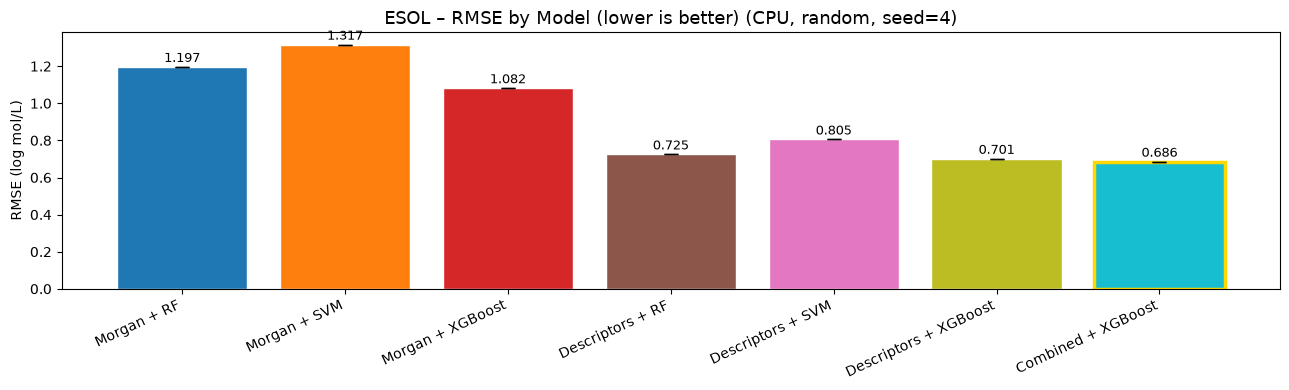

=== ESOL Results (7/12 models) ===
                                  RMSE              MAE               R2
Model                                                                   
Morgan + RF            1.1965 ± 0.0000  0.9368 ± 0.0000  0.6492 ± 0.0000
Morgan + SVM           1.3166 ± 0.0000  1.0309 ± 0.0000  0.5753 ± 0.0000
Morgan + XGBoost       1.0818 ± 0.0000  0.7959 ± 0.0000  0.7133 ± 0.0000
Descriptors + RF       0.7249 ± 0.0000  0.5444 ± 0.0000  0.8713 ± 0.0000
Descriptors + SVM      0.8052 ± 0.0000  0.5442 ± 0.0000  0.8412 ± 0.0000
Descriptors + XGBoost  0.7012 ± 0.0000  0.5232 ± 0.0000  0.8795 ± 0.0000
Combined + XGBoost     0.6857 ± 0.0000  0.5214 ± 0.0000  0.8848 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/esol_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/ran

,RMSE,MAE,R2
Model,,,
Morgan + RF,1.1965 ± 0.0000,0.9368 ± 0.0000,0.6492 ± 0.0000
Morgan + SVM,1.3166 ± 0.0000,1.0309 ± 0.0000,0.5753 ± 0.0000
Morgan + XGBoost,1.0818 ± 0.0000,0.7959 ± 0.0000,0.7133 ± 0.0000
Descriptors + RF,0.7249 ± 0.0000,0.5444 ± 0.0000,0.8713 ± 0.0000
Descriptors + SVM,0.8052 ± 0.0000,0.5442 ± 0.0000,0.8412 ± 0.0000
Descriptors + XGBoost,0.7012 ± 0.0000,0.5232 ± 0.0000,0.8795 ± 0.0000
Combined + XGBoost,0.6857 ± 0.0000,0.5214 ± 0.0000,0.8848 ± 0.0000


In [13]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE, plot_title=f"ESOL – RMSE by Model (lower is better) (CPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (log mol/L)", minimize=True)
